Leyendo datos de la capa Gold...


<Figure size 1200x600 with 0 Axes>

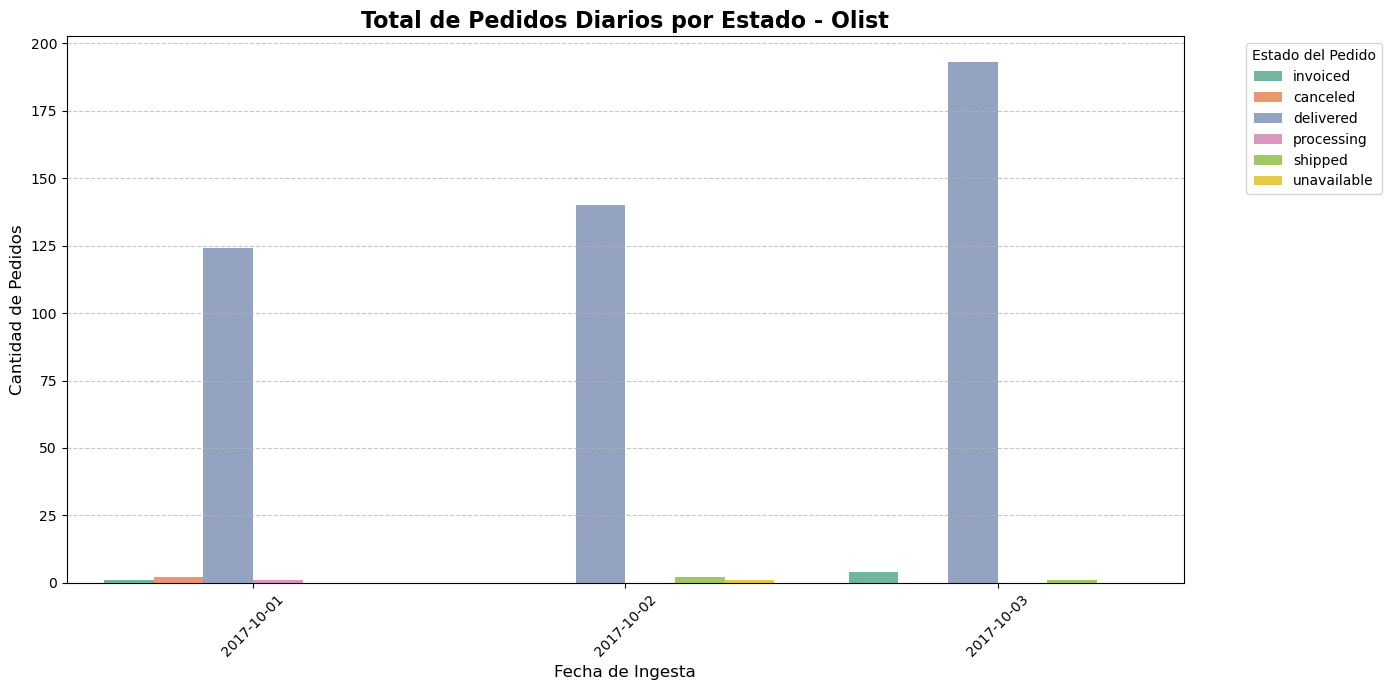


Tabla resumen de la capa Gold:


,ingestion_date,order_status,total_orders,avg_delivery_days
0,2017-10-01,invoiced,1,NaN
1,2017-10-01,canceled,2,NaN
2,2017-10-01,delivered,124,11.92
3,2017-10-01,processing,1,NaN
4,2017-10-02,delivered,140,10.89
5,2017-10-02,shipped,2,NaN
6,2017-10-02,unavailable,1,NaN
7,2017-10-03,shipped,1,NaN
8,2017-10-03,invoiced,4,NaN
9,2017-10-03,delivered,193,11.20


In [ ]:
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Encendemos el motor de Spark preparado para leer Delta
spark = SparkSession.builder \
    .appName("Visualizacion_Gold") \
    .config("spark.jars.packages", "io.delta:delta-spark_2.12:3.1.0") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .getOrCreate()

# 2. Leemos la capa Gold (Nota la ruta de Jupyter)
ruta_gold = "/home/jovyan/work/data/lakehouse/gold/daily_orders_summary"

print("Leyendo datos de la capa Gold...")
df_gold = spark.read.format("delta").load(ruta_gold)

# 3. Ordenamos cronológicamente
df_gold_sorted = df_gold.orderBy("ingestion_date")

# 4. El truco del Data Engineer: Pasar a Pandas
# Spark es genial para Big Data, pero Matplotlib necesita Pandas.
# Como la capa Gold ya está agrupada y resumida, es una tabla pequeñita y segura de convertir.
pandas_df = df_gold_sorted.toPandas()

# 5. ¡A graficar!
plt.figure(figsize=(12, 6))



"""
# Imprimimos los nombres exactos de las columnas
print("Mis columnas reales son:", pandas_df.columns.tolist())

# Vemos las primeras 5 filas de la tabla para entender qué datos tiene
print("\nAsí se ve mi tabla:")
display(pandas_df.head())"""




# 5. ¡A graficar con tus columnas reales!
plt.figure(figsize=(14, 7))

# Usamos total_orders para el eje Y, y hue='order_status' para pintar las barras por estado
sns.barplot(
    data=pandas_df, 
    x='ingestion_date', 
    y='total_orders', 
    hue='order_status', 
    palette='Set2',
    errorbar=None
)

plt.title('Total de Pedidos Diarios por Estado - Olist', fontsize=16, fontweight='bold')
plt.xlabel('Fecha de Ingesta', fontsize=12)
plt.ylabel('Cantidad de Pedidos', fontsize=12)
plt.xticks(rotation=45) # Inclinamos las fechas
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Movemos la leyenda para que no tape las barras
plt.legend(title='Estado del Pedido', bbox_to_anchor=(1.05, 1), loc='upper left')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

# (Opcional) Mostrar los números exactos
print("\nTabla resumen de la capa Gold:")
display(pandas_df)